# Assignment 2 — Remaining Face Verification Pipeline (Kaggle)

This notebook starts **after the AgeDB 200-subject dataset has already been created**.



## Pipeline
1. Locate and extract the prepared ZIP
2. Validate subjects, images, ages, age gaps and gender
3. MTCNN face detection and alignment
4. FaceNet embeddings
5. Genuine and impostor verification pairs
6. Original-image evaluation
7. Gaussian-noise evaluation
8. Salt-and-pepper-noise evaluation
9. Optional synthetic/GAN evaluation
10. FMR, FNMR, ROC, AUC and EER
11. Comparison plots
12. Save all numerical results
13. Create a final ZIP

**Recommended Kaggle setting:** GPU accelerator.

In [1]:
# CELL 1 — INSTALL FACENET-PYTORCH WITHOUT MODIFYING KAGGLE'S NUMPY/TORCH STACK

!pip install -q --no-deps facenet-pytorch

print("facenet-pytorch ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.3 MB/s eta 0:00:0000:01
facenet-pytorch ready.


In [2]:
# CELL 2 — IMPORTS AND CONFIGURATION

import os
import re
import json
import math
import random
import shutil
import zipfile
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.metrics import roc_curve, roc_auc_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Device: cuda
Torch: 2.10.0+cu128
NumPy: 2.0.2
Pandas: 2.3.3


## Step 1 — Locate the prepared ZIP

Attach your prepared ZIP through:

**Kaggle → Notebook → Add Input → Upload Dataset / select your dataset**

Do not hard-code the Kaggle dataset slug. The following cell searches `/kaggle/input` automatically.

In [3]:
# CELL 3 — FIND ALREADY-EXTRACTED DATASET

from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

# Find folders containing subject_001, subject_002, etc.
candidate_roots = []

for p in INPUT_ROOT.rglob("subject_001"):
    if p.is_dir():
        candidate_roots.append(p.parent)

print("Possible dataset roots:")

for p in candidate_roots:
    print(" ", p)

if not candidate_roots:
    raise FileNotFoundError(
        "Could not find subject_001 under /kaggle/input."
    )

# Use the first matching dataset root
DATASET_DIR = candidate_roots[0]

print("\nUsing dataset:")
print(DATASET_DIR)

# Find subject folders
subject_dirs = sorted(
    [
        p for p in DATASET_DIR.iterdir()
        if p.is_dir() and re.fullmatch(r"subject_\d+", p.name)
    ]
)

print("\nNumber of subject folders:", len(subject_dirs))

print("\nFirst 10 subjects:")
for p in subject_dirs[:10]:
    print(" ", p.name)

# Find metadata
metadata_candidates = list(DATASET_DIR.rglob("metadata.csv"))

if metadata_candidates:
    METADATA_PATH = metadata_candidates[0]
    print("\nMetadata found:")
    print(METADATA_PATH)
else:
    METADATA_PATH = None
    print("\nWARNING: metadata.csv was not found.")

Possible dataset roots:
  /kaggle/input/datasets/vidwathkumar/images

Using dataset:
/kaggle/input/datasets/vidwathkumar/images

Number of subject folders: 200

First 10 subjects:
  subject_001
  subject_002
  subject_003
  subject_004
  subject_005
  subject_006
  subject_007
  subject_008
  subject_009
  subject_010

Metadata found:
/kaggle/input/datasets/vidwathkumar/images/metadata.csv


In [ ]:
# CELL 4 — USE ALREADY-EXTRACTED DATASET

EXTRACT_ROOT = DATASET_DIR

print("Using existing dataset:")
print(EXTRACT_ROOT)

# Verify subject folders
subject_dirs = sorted(
    [
        p for p in EXTRACT_ROOT.iterdir()
        if p.is_dir() and re.fullmatch(r"subject_\d+", p.name)
    ]
)

print("\nNumber of subject folders:", len(subject_dirs))

# Count images
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

image_files = [
    p for p in EXTRACT_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("Number of image files:", len(image_files))

# Metadata
metadata_candidates = list(
    EXTRACT_ROOT.rglob("metadata.csv")
)

if metadata_candidates:
    METADATA_PATH = metadata_candidates[0]
    print("\nMetadata:")
    print(METADATA_PATH)
else:
    METADATA_PATH = None
    print("\nWARNING: metadata.csv not found.")

# Show sample files
print("\nSample image files:")

for p in image_files[:10]:
    print(" ", p)

Using existing dataset:
/kaggle/input/datasets/vidwathkumar/images

Number of subject folders: 200
Number of image files: 400

Metadata:
/kaggle/input/datasets/vidwathkumar/images/metadata.csv

Sample image files:
  /kaggle/input/datasets/vidwathkumar/images/subject_070/subject_070_img2_age34.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_070/subject_070_img1_age25.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_124/subject_124_img2_age36.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_124/subject_124_img1_age27.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_197/subject_197_img1_age23.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_197/subject_197_img2_age32.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_173/subject_173_img1_age19.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_173/subject_173_img2_age28.jpg
  /kaggle/input/datasets/vidwathkumar/images/subject_106/subject_106_img1_age35.jpg
  /kaggle/input/datasets/vidwa

In [5]:
# CELL 5 — LOCATE METADATA

metadata_files = list(
    EXTRACT_ROOT.rglob("metadata.csv")
)

if not metadata_files:
    raise FileNotFoundError(
        "metadata.csv was not found inside the ZIP."
    )

METADATA_PATH = metadata_files[0]
DATASET_DIR = METADATA_PATH.parent

print("Dataset directory:", DATASET_DIR)
print("Metadata:", METADATA_PATH)

Dataset directory: /kaggle/input/datasets/vidwathkumar/images
Metadata: /kaggle/input/datasets/vidwathkumar/images/metadata.csv


In [6]:
# CELL 6 — LOAD METADATA AND RESOLVE IMAGE PATHS

metadata = pd.read_csv(
    METADATA_PATH
)

print("Metadata shape:", metadata.shape)
print("Columns:", metadata.columns.tolist())

display(
    metadata.head()
)

required = {
    "subject_id",
    "image_number",
    "age",
    "age_gap",
    "gender"
}

missing = required - set(
    metadata.columns
)

if missing:
    raise ValueError(
        f"Missing metadata columns: {missing}"
    )

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png"
}

all_images = [
    p for p in DATASET_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower()
    in image_extensions
]

print(
    "\nImages found:",
    len(all_images)
)

image_by_name = {
    p.name: p
    for p in all_images
}

def find_image(row):

    sid = str(row["subject_id"])
    ino = int(row["image_number"])

    subject_dir = (
        DATASET_DIR / sid
    )

    # Match image number first.
    matches = [
        p for p in subject_dir.glob("*")
        if p.is_file()
        and p.suffix.lower()
        in image_extensions
        and re.search(
            rf"_img{ino}(?:_|\.)",
            p.name
        )
    ]

    if matches:
        return str(matches[0])

    # Fallback: match exact expected naming pattern.
    expected = (
        f"{sid}_img{ino}_"
        f"age{int(row['age'])}.jpg"
    )

    if expected in image_by_name:
        return str(
            image_by_name[expected]
        )

    return None

metadata["resolved_path"] = [
    find_image(row)
    for _, row in metadata.iterrows()
]

print(
    "Resolved paths:",
    metadata["resolved_path"].notna().sum(),
    "/",
    len(metadata)
)

display(
    metadata.head()
)

Metadata shape: (400, 8)
Columns: ['subject_id', 'image_number', 'age', 'age_gap', 'gender', 'original_identity', 'original_path', 'new_path']


,subject_id,image_number,age,age_gap,gender,original_identity,original_path,new_path
0,subject_001,1,33,9,m,tomselleck,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_001/...
1,subject_001,2,42,9,m,tomselleck,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_001/...
2,subject_002,1,49,9,m,Abe Vigoda,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_002/...
3,subject_002,2,58,9,m,Abe Vigoda,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_002/...
4,subject_003,1,43,9,m,Adolf Hitlerr,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_003/...



Images found: 400
Resolved paths: 400 / 400


,subject_id,image_number,age,age_gap,gender,original_identity,original_path,new_path,resolved_path
0,subject_001,1,33,9,m,tomselleck,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_001/...,/kaggle/input/datasets/vidwathkumar/images/sub...
1,subject_001,2,42,9,m,tomselleck,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_001/...,/kaggle/input/datasets/vidwathkumar/images/sub...
2,subject_002,1,49,9,m,Abe Vigoda,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_002/...,/kaggle/input/datasets/vidwathkumar/images/sub...
3,subject_002,2,58,9,m,Abe Vigoda,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_002/...,/kaggle/input/datasets/vidwathkumar/images/sub...
4,subject_003,1,43,9,m,Adolf Hitlerr,/kaggle/input/datasets/shukdevdatta/agedb-clas...,/kaggle/working/AgeDB_Assignment2/subject_003/...,/kaggle/input/datasets/vidwathkumar/images/sub...


In [7]:
# CELL 7 — FINAL DATASET VALIDATION

print("=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

subject_counts = (
    metadata.groupby("subject_id")
    .size()
)

num_subjects = metadata[
    "subject_id"
].nunique()

num_images = len(metadata)

subject_gaps = (
    metadata.groupby("subject_id")[
        "age_gap"
    ].first()
)

print("Subjects:", num_subjects)
print("Images:", num_images)

print(
    "Images per subject:",
    subject_counts.unique().tolist()
)

print(
    "Minimum age:",
    metadata["age"].min()
)

print(
    "Maximum age:",
    metadata["age"].max()
)

print(
    "Average age:",
    round(
        metadata["age"].mean(),
        2
    )
)

print(
    "Average age gap:",
    round(
        subject_gaps.mean(),
        2
    )
)

print(
    "Maximum age gap:",
    subject_gaps.max()
)

print(
    "Subjects with age gap < 10:",
    int(
        (subject_gaps < 10).sum()
    ),
    "/",
    len(subject_gaps)
)

print(
    "Missing image paths:",
    metadata["resolved_path"].isna().sum()
)

print("\nGender distribution:")

print(
    metadata.groupby("subject_id")[
        "gender"
    ].first().value_counts()
)

assert num_subjects >= 200
assert subject_counts.min() >= 2
assert metadata["resolved_path"].notna().all()

print(
    "\n✓ DATASET VALIDATION PASSED"
)

FINAL DATASET VALIDATION
Subjects: 200
Images: 400
Images per subject: [2]
Minimum age: 7
Maximum age: 89
Average age: 31.12
Average age gap: 9.0
Maximum age gap: 9
Subjects with age gap < 10: 200 / 200
Missing image paths: 0

Gender distribution:
gender
m    116
f     84
Name: count, dtype: int64

✓ DATASET VALIDATION PASSED


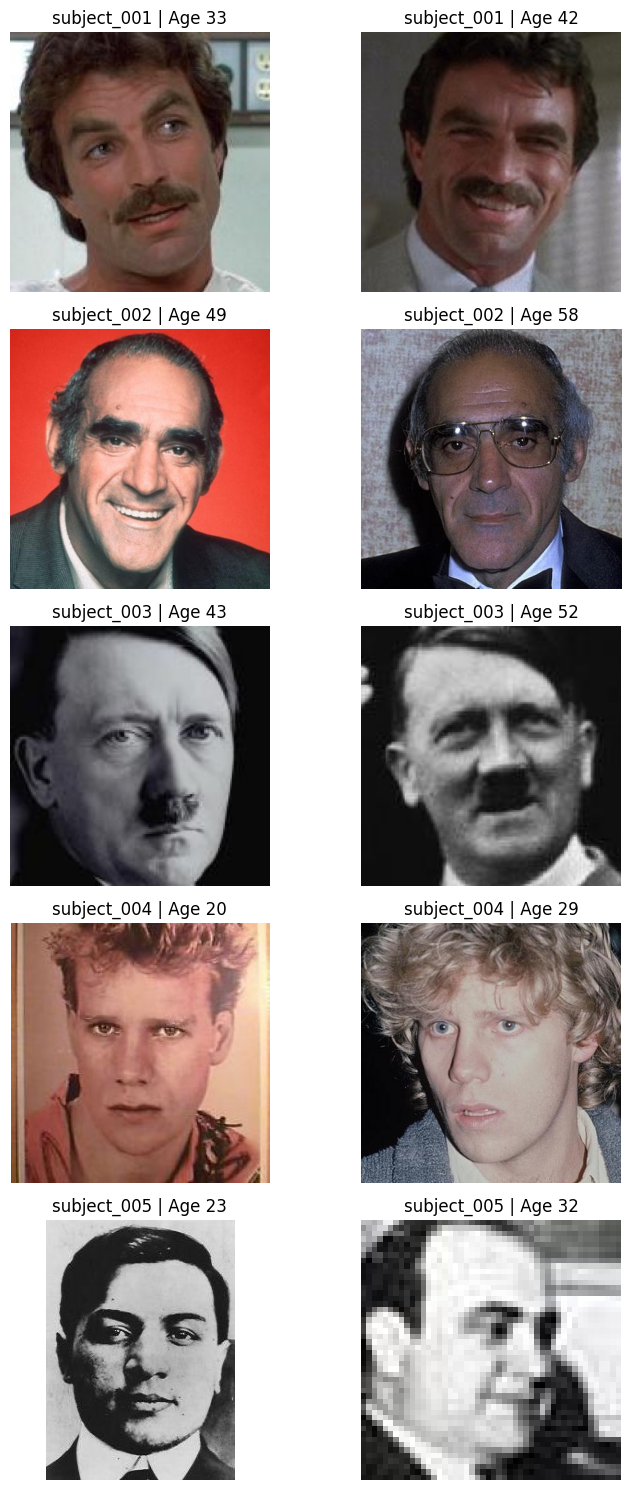

In [8]:
# CELL 8 — DISPLAY SAMPLE PAIRS

sample_subjects = (
    metadata["subject_id"]
    .drop_duplicates()
    .head(5)
)

fig, axes = plt.subplots(
    len(sample_subjects),
    2,
    figsize=(8, 3 * len(sample_subjects))
)

if len(sample_subjects) == 1:
    axes = np.array([axes])

for r, sid in enumerate(
    sample_subjects
):

    rows = (
        metadata[
            metadata["subject_id"] == sid
        ]
        .sort_values("image_number")
        .head(2)
    )

    for c, (_, row) in enumerate(
        rows.iterrows()
    ):

        img = Image.open(
            row["resolved_path"]
        ).convert("RGB")

        axes[r, c].imshow(img)

        axes[r, c].set_title(
            f"{sid} | "
            f"Age {int(row['age'])}"
        )

        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

## Step 2 — MTCNN face detection and alignment

MTCNN is used to detect the face and generate a standardized 160×160 face crop.

Detection failures are explicitly recorded.

In [9]:
# CELL 9 — INITIALIZE MTCNN AND FACENET

mtcnn = MTCNN(
    image_size=160,
    margin=20,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=True,
    device=DEVICE
)

facenet = (
    InceptionResnetV1(
        pretrained="vggface2"
    )
    .eval()
    .to(DEVICE)
)

print("MTCNN ready.")
print("FaceNet ready.")

  0%|          | 0.00/107M [00:00<?, ?B/s]

MTCNN ready.
FaceNet ready.


In [10]:
# CELL 10 — MTCNN DETECTION AND FACE ALIGNMENT
# Compatible with current facenet-pytorch versions

OUTPUT_ROOT = Path("/kaggle/working/Assignment2_Output")
ALIGNED_ORIGINAL = OUTPUT_ROOT / "aligned_original"

if ALIGNED_ORIGINAL.exists():
    shutil.rmtree(ALIGNED_ORIGINAL)

ALIGNED_ORIGINAL.mkdir(
    parents=True,
    exist_ok=True
)

detection_records = []

detect_success = 0
alignment_success = 0


for _, row in tqdm(
    metadata.iterrows(),
    total=len(metadata),
    desc="MTCNN — original"
):

    sid = str(row["subject_id"])
    ino = int(row["image_number"])
    src = Path(row["resolved_path"])

    record = {
        "subject_id": sid,
        "image_number": ino,
        "source_path": str(src),
        "face_detected": False,
        "face_extracted": False,
        "confidence": np.nan,
        "aligned_path": None,
        "error": None
    }

    try:

        # -------------------------
        # 1. LOAD IMAGE
        # -------------------------

        img = Image.open(src).convert("RGB")

        # -------------------------
        # 2. MTCNN FACE DETECTION
        # -------------------------

        boxes, probs = mtcnn.detect(img)

        if boxes is None or probs is None:
            record["error"] = "No face detected"
            detection_records.append(record)
            continue

        boxes = np.asarray(boxes)

        # facenet-pytorch may return a scalar
        # when only one face is detected.
        if boxes.ndim == 1:
            boxes = boxes.reshape(1, -1)

        # Convert probability safely
        if np.isscalar(probs):
            probs = np.array([float(probs)])
        else:
            probs = np.asarray(probs, dtype=float).reshape(-1)

        if len(boxes) == 0:
            record["error"] = "Empty detection"
            detection_records.append(record)
            continue

        # -------------------------
        # 3. SELECT BEST FACE
        # -------------------------

        best = int(np.argmax(probs))

        box = boxes[best]

        confidence = float(probs[best])

        record["face_detected"] = True
        record["confidence"] = confidence

        detect_success += 1

        # -------------------------
        # 4. CROP FACE
        # -------------------------

        x1, y1, x2, y2 = [
            int(round(v))
            for v in box[:4]
        ]

        # Clamp coordinates to image boundaries
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img.width, x2)
        y2 = min(img.height, y2)

        if x2 <= x1 or y2 <= y1:
            record["error"] = "Invalid face bounding box"
            detection_records.append(record)
            continue

        face = img.crop(
            (x1, y1, x2, y2)
        )

        # -------------------------
        # 5. RESIZE TO FACENET INPUT
        # -------------------------

        face = face.resize(
            (160, 160),
            Image.Resampling.BILINEAR
        )

        # -------------------------
        # 6. SAVE ALIGNED FACE
        # -------------------------

        out_dir = ALIGNED_ORIGINAL / sid

        out_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        out_path = (
            out_dir /
            f"{sid}_img{ino}.png"
        )

        face.save(out_path)

        record["face_extracted"] = True
        record["aligned_path"] = str(out_path)

        alignment_success += 1

    except Exception as e:

        record["error"] = (
            f"{type(e).__name__}: {e}"
        )

    detection_records.append(record)


# -------------------------
# RESULTS
# -------------------------

detection_df = pd.DataFrame(
    detection_records
)

print("\n==============================")
print("MTCNN RESULTS")
print("==============================")

print(
    "Detection successful:",
    detect_success,
    "/",
    len(detection_df)
)

print(
    "Alignment successful:",
    alignment_success,
    "/",
    len(detection_df)
)

print(
    "Detection rate:",
    round(
        detection_df[
            "face_detected"
        ].mean() * 100,
        2
    ),
    "%"
)

print(
    "Alignment rate:",
    round(
        detection_df[
            "face_extracted"
        ].mean() * 100,
        2
    ),
    "%"
)

print("\nMost common errors:")

errors = detection_df.loc[
    detection_df["error"].notna(),
    "error"
].value_counts()

display(errors.head(15))

print("\nFirst records:")

display(
    detection_df.head(10)
)

MTCNN — original:   0%|          | 0/400 [00:00<?, ?it/s]


MTCNN RESULTS
Detection successful: 399 / 400
Alignment successful: 399 / 400
Detection rate: 99.75 %
Alignment rate: 99.75 %

Most common errors:


error
No face detected    1
Name: count, dtype: int64


First records:


,subject_id,image_number,source_path,face_detected,face_extracted,confidence,aligned_path,error
0,subject_001,1,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.999994,/kaggle/working/Assignment2_Output/aligned_ori...,None
1,subject_001,2,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.999998,/kaggle/working/Assignment2_Output/aligned_ori...,None
2,subject_002,1,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.999968,/kaggle/working/Assignment2_Output/aligned_ori...,None
3,subject_002,2,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.999345,/kaggle/working/Assignment2_Output/aligned_ori...,None
4,subject_003,1,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.999817,/kaggle/working/Assignment2_Output/aligned_ori...,None
5,subject_003,2,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.997608,/kaggle/working/Assignment2_Output/aligned_ori...,None
6,subject_004,1,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.985557,/kaggle/working/Assignment2_Output/aligned_ori...,None
7,subject_004,2,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.995902,/kaggle/working/Assignment2_Output/aligned_ori...,None
8,subject_005,1,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.999721,/kaggle/working/Assignment2_Output/aligned_ori...,None
9,subject_005,2,/kaggle/input/datasets/vidwathkumar/images/sub...,True,True,0.953670,/kaggle/working/Assignment2_Output/aligned_ori...,None


In [11]:
# CELL 11 — KEEP SUBJECTS WITH BOTH FACES DETECTED

detected = detection_df[
    detection_df["face_detected"]
].copy()

counts = (
    detected.groupby("subject_id")
    .size()
)

valid_subjects = counts[
    counts >= 2
].index

print(
    "Valid subjects:",
    len(valid_subjects)
)

print(
    "Subjects lost:",
    metadata["subject_id"].nunique()
    - len(valid_subjects)
)

evaluation_metadata = (
    metadata[
        metadata["subject_id"].isin(
            valid_subjects
        )
    ]
    .merge(
        detected[
            [
                "subject_id",
                "image_number",
                "confidence",
                "aligned_path"
            ]
        ],
        on=[
            "subject_id",
            "image_number"
        ],
        how="inner"
    )
    .sort_values(
        [
            "subject_id",
            "image_number"
        ]
    )
    .reset_index(drop=True)
)

print(
    "Evaluation images:",
    len(evaluation_metadata)
)

print(
    "Evaluation subjects:",
    evaluation_metadata[
        "subject_id"
    ].nunique()
)

if len(
    evaluation_metadata["subject_id"].unique()
) < 200:
    print(
        "\nWARNING: MTCNN reduced the dataset "
        "below 200 subjects."
    )

Valid subjects: 199
Subjects lost: 1
Evaluation images: 398
Evaluation subjects: 199



## Step 3 — FaceNet embeddings

In [12]:
# CELL 12 — FACENET EMBEDDING FUNCTION

def pil_to_tensor(image):

    image = image.resize(
        (160, 160)
    )

    arr = np.asarray(
        image,
        dtype=np.float32
    )

    arr = (
        arr - 127.5
    ) / 128.0

    return torch.from_numpy(
        arr
    ).permute(2, 0, 1)


@torch.no_grad()
def embed_paths(
    paths,
    batch_size=64
):

    outputs = []

    for start in tqdm(
        range(
            0,
            len(paths),
            batch_size
        ),
        desc="FaceNet"
    ):

        batch_paths = paths[
            start:start + batch_size
        ]

        tensors = []

        for p in batch_paths:

            img = Image.open(
                p
            ).convert("RGB")

            tensors.append(
                pil_to_tensor(img)
            )

        batch = torch.stack(
            tensors
        ).to(DEVICE)

        emb = facenet(batch)

        emb = F.normalize(
            emb,
            p=2,
            dim=1
        )

        outputs.append(
            emb.cpu().numpy()
        )

    return np.vstack(
        outputs
    )

In [13]:
# CELL 13 — ORIGINAL EMBEDDINGS

original_embeddings = embed_paths(
    evaluation_metadata[
        "aligned_path"
    ].tolist()
)

print(
    "Embedding shape:",
    original_embeddings.shape
)

original_lookup = {
    (
        row["subject_id"],
        int(row["image_number"])
    ): original_embeddings[i]
    for i, (_, row)
    in enumerate(
        evaluation_metadata.iterrows()
    )
}

FaceNet:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding shape: (398, 512)


## Step 4 — Genuine and impostor comparisons

Genuine:
- two images belonging to the same subject.

Impostor:
- images belonging to different subjects.

The default experiment uses 5,000 randomly sampled impostor subject pairs, or all available pairs if fewer exist.

In [14]:
# CELL 14 — CREATE VERIFICATION PAIRS

subject_ids = sorted(
    evaluation_metadata[
        "subject_id"
    ].unique()
)

genuine_pairs = []

for sid in subject_ids:

    rows = (
        evaluation_metadata[
            evaluation_metadata[
                "subject_id"
            ] == sid
        ]
        .sort_values("image_number")
    )

    if len(rows) >= 2:

        genuine_pairs.append(
            (
                sid,
                int(
                    rows.iloc[0][
                        "image_number"
                    ]
                ),
                sid,
                int(
                    rows.iloc[1][
                        "image_number"
                    ]
                )
            )
        )

all_impostor_subject_pairs = list(
    combinations(
        subject_ids,
        2
    )
)

rng = random.Random(
    SEED
)

NUM_IMPOSTOR_PAIRS = min(
    5000,
    len(
        all_impostor_subject_pairs
    )
)

selected_impostor_subject_pairs = (
    rng.sample(
        all_impostor_subject_pairs,
        NUM_IMPOSTOR_PAIRS
    )
)

impostor_pairs = []

for sid1, sid2 in (
    selected_impostor_subject_pairs
):

    rows1 = (
        evaluation_metadata[
            evaluation_metadata[
                "subject_id"
            ] == sid1
        ]
        .sort_values("image_number")
    )

    rows2 = (
        evaluation_metadata[
            evaluation_metadata[
                "subject_id"
            ] == sid2
        ]
        .sort_values("image_number")
    )

    impostor_pairs.append(
        (
            sid1,
            int(
                rows1.iloc[0][
                    "image_number"
                ]
            ),
            sid2,
            int(
                rows2.iloc[0][
                    "image_number"
                ]
            )
        )
    )

print(
    "Genuine pairs:",
    len(genuine_pairs)
)

print(
    "Impostor pairs:",
    len(impostor_pairs)
)

Genuine pairs: 199
Impostor pairs: 5000


In [15]:
# CELL 15 — SCORING AND EVALUATION FUNCTIONS

def cosine_similarity(a, b):

    return float(
        np.dot(a, b)
        / (
            np.linalg.norm(a)
            * np.linalg.norm(b)
            + 1e-12
        )
    )


def score_pairs(
    lookup,
    genuine,
    impostor
):

    gs = [
        cosine_similarity(
            lookup[(a, b)],
            lookup[(c, d)]
        )
        for a, b, c, d in genuine
    ]

    ims = [
        cosine_similarity(
            lookup[(a, b)],
            lookup[(c, d)]
        )
        for a, b, c, d in impostor
    ]

    return (
        np.array(gs),
        np.array(ims)
    )


def evaluate_scores(
    genuine_scores,
    impostor_scores,
    condition
):

    y_true = np.concatenate([
        np.ones(
            len(genuine_scores)
        ),
        np.zeros(
            len(impostor_scores)
        )
    ])

    y_score = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    fpr, tpr, thresholds = (
        roc_curve(
            y_true,
            y_score
        )
    )

    fnr = 1 - tpr

    idx = np.nanargmin(
        np.abs(fpr - fnr)
    )

    eer = (
        fpr[idx] + fnr[idx]
    ) / 2

    threshold = thresholds[idx]

    auc = roc_auc_score(
        y_true,
        y_score
    )

    fmr = np.mean(
        impostor_scores >= threshold
    )

    fnmr = np.mean(
        genuine_scores < threshold
    )

    result = {
        "condition": condition,
        "genuine_pairs":
            len(genuine_scores),
        "impostor_pairs":
            len(impostor_scores),
        "mean_genuine_score":
            float(
                genuine_scores.mean()
            ),
        "mean_impostor_score":
            float(
                impostor_scores.mean()
            ),
        "eer":
            float(eer),
        "eer_percent":
            float(eer * 100),
        "eer_threshold":
            float(threshold),
        "fmr_at_eer":
            float(fmr),
        "fnmr_at_eer":
            float(fnmr),
        "auc":
            float(auc)
    }

    curve = pd.DataFrame({
        "threshold": thresholds,
        "fmr": fpr,
        "tpr": tpr,
        "fnmr": fnr
    })

    return result, curve

In [16]:
# CELL 16 — ORIGINAL RESULTS

genuine_original, impostor_original = (
    score_pairs(
        original_lookup,
        genuine_pairs,
        impostor_pairs
    )
)

original_result, original_curve = (
    evaluate_scores(
        genuine_original,
        impostor_original,
        "Original"
    )
)

display(
    pd.DataFrame(
        [original_result]
    ).round(4)
)

,condition,genuine_pairs,impostor_pairs,mean_genuine_score,mean_impostor_score,eer,eer_percent,eer_threshold,fmr_at_eer,fnmr_at_eer,auc
0,Original,199,5000,0.5844,0.0769,0.0794,7.9401,0.3332,0.0784,0.0804,0.9762


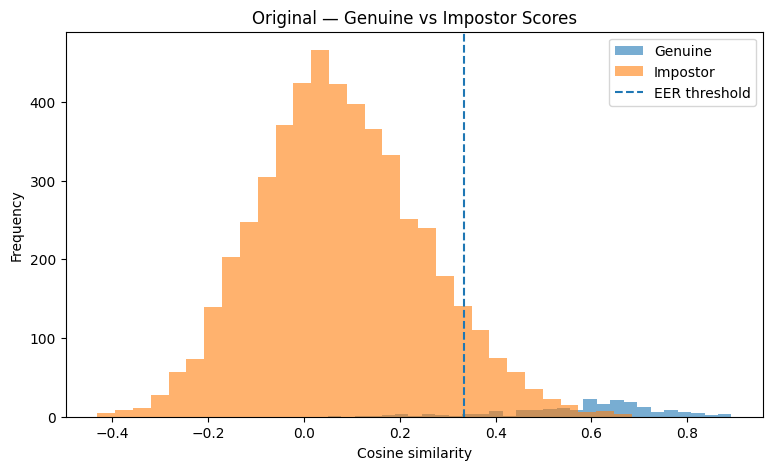

In [17]:
# CELL 17 — ORIGINAL SCORE DISTRIBUTION

plt.figure(figsize=(9, 5))

plt.hist(
    genuine_original,
    bins=30,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    impostor_original,
    bins=30,
    alpha=0.6,
    label="Impostor"
)

plt.axvline(
    original_result[
        "eer_threshold"
    ],
    linestyle="--",
    label="EER threshold"
)

plt.xlabel(
    "Cosine similarity"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Original — Genuine vs Impostor Scores"
)

plt.legend()
plt.show()

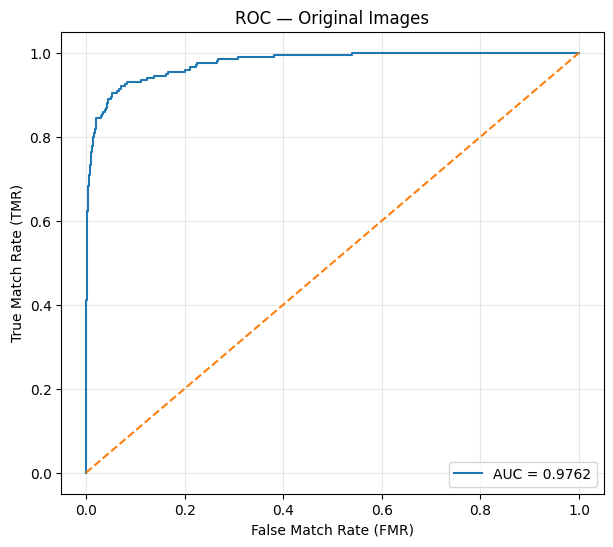

In [18]:
# CELL 18 — ORIGINAL ROC

plt.figure(figsize=(7, 6))

plt.plot(
    original_curve["fmr"],
    original_curve["tpr"],
    label=(
        f"AUC = "
        f"{original_result['auc']:.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Match Rate (FMR)"
)

plt.ylabel(
    "True Match Rate (TMR)"
)

plt.title(
    "ROC — Original Images"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 5 — Noise experiments

Noise is added to the original photographs and then passed through MTCNN and FaceNet again.

Default parameters:
- Gaussian noise: σ = 20
- Salt-and-pepper noise: 2% of pixels

In [19]:
# CELL 19 — NOISE FUNCTIONS

def add_gaussian_noise(
    image,
    sigma=20
):

    arr = np.asarray(
        image,
        dtype=np.float32
    )

    noise = np.random.normal(
        0,
        sigma,
        arr.shape
    )

    noisy = np.clip(
        arr + noise,
        0,
        255
    ).astype(np.uint8)

    return Image.fromarray(
        noisy
    )


def add_salt_pepper_noise(
    image,
    amount=0.02
):

    arr = np.asarray(
        image,
        dtype=np.uint8
    ).copy()

    h, w, _ = arr.shape

    n = int(
        amount * h * w
    )

    ys = np.random.randint(
        0,
        h,
        n
    )

    xs = np.random.randint(
        0,
        w,
        n
    )

    half = n // 2

    arr[
        ys[:half],
        xs[:half]
    ] = 255

    arr[
        ys[half:],
        xs[half:]
    ] = 0

    return Image.fromarray(
        arr
    )

In [20]:
# CELL 20 — CREATE NOISY IMAGES

NOISE_ROOT = (
    OUTPUT_ROOT / "noisy"
)

GAUSSIAN_DIR = (
    NOISE_ROOT / "gaussian"
)

SP_DIR = (
    NOISE_ROOT / "salt_pepper"
)

GAUSSIAN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

np.random.seed(SEED)

noise_rows = []

for _, row in tqdm(
    evaluation_metadata.iterrows(),
    total=len(evaluation_metadata),
    desc="Creating noise"
):

    sid = str(row["subject_id"])
    ino = int(row["image_number"])

    img = Image.open(
        row["resolved_path"]
    ).convert("RGB")

    gd = GAUSSIAN_DIR / sid
    sd = SP_DIR / sid

    gd.mkdir(
        parents=True,
        exist_ok=True
    )

    sd.mkdir(
        parents=True,
        exist_ok=True
    )

    gp = (
        gd /
        f"{sid}_img{ino}.jpg"
    )

    sp = (
        sd /
        f"{sid}_img{ino}.jpg"
    )

    add_gaussian_noise(
        img,
        sigma=20
    ).save(
        gp,
        quality=95
    )

    add_salt_pepper_noise(
        img,
        amount=0.02
    ).save(
        sp,
        quality=95
    )

    noise_rows.append({
        "subject_id": sid,
        "image_number": ino,
        "gaussian_path": str(gp),
        "salt_pepper_path": str(sp)
    })

noise_df = pd.DataFrame(
    noise_rows
)

display(
    noise_df.head()
)

Creating noise:   0%|          | 0/398 [00:00<?, ?it/s]

,subject_id,image_number,gaussian_path,salt_pepper_path
0,subject_001,1,/kaggle/working/Assignment2_Output/noisy/gauss...,/kaggle/working/Assignment2_Output/noisy/salt_...
1,subject_001,2,/kaggle/working/Assignment2_Output/noisy/gauss...,/kaggle/working/Assignment2_Output/noisy/salt_...
2,subject_002,1,/kaggle/working/Assignment2_Output/noisy/gauss...,/kaggle/working/Assignment2_Output/noisy/salt_...
3,subject_002,2,/kaggle/working/Assignment2_Output/noisy/gauss...,/kaggle/working/Assignment2_Output/noisy/salt_...
4,subject_003,1,/kaggle/working/Assignment2_Output/noisy/gauss...,/kaggle/working/Assignment2_Output/noisy/salt_...


In [21]:
# FIXED process_condition()

def process_condition(
    condition_df,
    path_column,
    condition_name
):

    detection_records = []
    lookup = {}

    for _, row in tqdm(
        condition_df.iterrows(),
        total=len(condition_df),
        desc=f"MTCNN + FaceNet — {condition_name}"
    ):

        sid = str(row["subject_id"])
        ino = int(row["image_number"])
        src = Path(row[path_column])

        detected = False
        confidence = np.nan
        embedding = None
        error = None

        try:

            # -------------------------
            # LOAD NOISY IMAGE
            # -------------------------

            img = Image.open(src).convert("RGB")

            # -------------------------
            # MTCNN DETECTION
            # -------------------------

            boxes, probs = mtcnn.detect(img)

            if boxes is None or probs is None:
                raise ValueError("No face detected")

            boxes = np.asarray(boxes)

            if boxes.ndim == 1:
                boxes = boxes.reshape(1, -1)

            if np.isscalar(probs):
                probs = np.array([float(probs)])
            else:
                probs = np.asarray(
                    probs,
                    dtype=float
                ).reshape(-1)

            if len(boxes) == 0:
                raise ValueError("No valid face box")

            best = int(np.argmax(probs))

            box = boxes[best]

            confidence = float(probs[best])

            # -------------------------
            # CROP FACE
            # -------------------------

            x1, y1, x2, y2 = [
                int(round(v))
                for v in box[:4]
            ]

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img.width, x2)
            y2 = min(img.height, y2)

            if x2 <= x1 or y2 <= y1:
                raise ValueError(
                    "Invalid face bounding box"
                )

            face = img.crop(
                (x1, y1, x2, y2)
            )

            face = face.resize(
                (160, 160),
                Image.Resampling.BILINEAR
            )

            # -------------------------
            # FACENET PREPROCESSING
            # -------------------------

            arr = np.asarray(
                face
            ).astype(np.float32)

            arr = (
                arr - 127.5
            ) / 128.0

            tensor = torch.from_numpy(
                arr
            )

            tensor = tensor.permute(
                2, 0, 1
            )

            tensor = tensor.unsqueeze(
                0
            ).to(DEVICE)

            # -------------------------
            # FACENET EMBEDDING
            # -------------------------

            with torch.no_grad():

                emb = facenet(
                    tensor
                )

                emb = F.normalize(
                    emb,
                    p=2,
                    dim=1
                )

            embedding = (
                emb.squeeze(0)
                .cpu()
                .numpy()
            )

            detected = True

            # IMPORTANT:
            # Save lookup using the exact
            # (subject_id, image_number) key
            lookup[
                (sid, ino)
            ] = embedding

        except Exception as e:

            error = (
                f"{type(e).__name__}: {e}"
            )

        detection_records.append({
            "subject_id": sid,
            "image_number": ino,
            "detected": detected,
            "confidence": confidence,
            "error": error
        })

    detection_df = pd.DataFrame(
        detection_records
    )

    return detection_df, lookup

In [25]:
# CELL 21.5 — FILTER PAIRS FOR AVAILABLE EMBEDDINGS

def filter_pairs(pairs, lookup):
    """
    Keep only pairs for which embeddings are available.

    Each pair is expected to contain:
        (subject1, image1, subject2, image2)
    """

    valid_pairs = []

    for pair in pairs:

        sid1, ino1, sid2, ino2 = pair

        key1 = (
            str(sid1),
            int(ino1)
        )

        key2 = (
            str(sid2),
            int(ino2)
        )

        if (
            key1 in lookup
            and key2 in lookup
        ):
            valid_pairs.append(pair)

    return valid_pairs


print("filter_pairs() is ready.")

filter_pairs() is ready.


In [26]:
# CELL 22 — GAUSSIAN CONDITION

gaussian_detection, gaussian_lookup = (
    process_condition(
        noise_df,
        "gaussian_path",
        "Gaussian"
    )
)

genuine_gaussian_pairs = (
    filter_pairs(
        genuine_pairs,
        gaussian_lookup
    )
)

impostor_gaussian_pairs = (
    filter_pairs(
        impostor_pairs,
        gaussian_lookup
    )
)

print(
    "Detected:",
    int(
        gaussian_detection[
            "detected"
        ].sum()
    ),
    "/",
    len(gaussian_detection)
)

print(
    "Usable genuine pairs:",
    len(
        genuine_gaussian_pairs
    )
)

print(
    "Usable impostor pairs:",
    len(
        impostor_gaussian_pairs
    )
)

MTCNN + FaceNet — Gaussian:   0%|          | 0/398 [00:00<?, ?it/s]

Detected: 396 / 398
Usable genuine pairs: 197
Usable impostor pairs: 4946


In [27]:
# CELL 23 — SALT-AND-PEPPER CONDITION

sp_detection, sp_lookup = (
    process_condition(
        noise_df,
        "salt_pepper_path",
        "SaltPepper"
    )
)

genuine_sp_pairs = (
    filter_pairs(
        genuine_pairs,
        sp_lookup
    )
)

impostor_sp_pairs = (
    filter_pairs(
        impostor_pairs,
        sp_lookup
    )
)

print(
    "Detected:",
    int(
        sp_detection[
            "detected"
        ].sum()
    ),
    "/",
    len(sp_detection)
)

print(
    "Usable genuine pairs:",
    len(
        genuine_sp_pairs
    )
)

print(
    "Usable impostor pairs:",
    len(
        impostor_sp_pairs
    )
)

MTCNN + FaceNet — SaltPepper:   0%|          | 0/398 [00:00<?, ?it/s]

Detected: 394 / 398
Usable genuine pairs: 195
Usable impostor pairs: 4946


In [28]:
# CELL 24 — GAUSSIAN RESULTS

genuine_gaussian, impostor_gaussian = (
    score_pairs(
        gaussian_lookup,
        genuine_gaussian_pairs,
        impostor_gaussian_pairs
    )
)

gaussian_result, gaussian_curve = (
    evaluate_scores(
        genuine_gaussian,
        impostor_gaussian,
        "Gaussian Noise"
    )
)

display(
    pd.DataFrame(
        [gaussian_result]
    ).round(4)
)

,condition,genuine_pairs,impostor_pairs,mean_genuine_score,mean_impostor_score,eer,eer_percent,eer_threshold,fmr_at_eer,fnmr_at_eer,auc
0,Gaussian Noise,197,4946,0.5737,0.1318,0.1128,11.2752,0.3582,0.1138,0.1117,0.9562


In [29]:
# CELL 25 — SALT-AND-PEPPER RESULTS

genuine_sp, impostor_sp = (
    score_pairs(
        sp_lookup,
        genuine_sp_pairs,
        impostor_sp_pairs
    )
)

sp_result, sp_curve = (
    evaluate_scores(
        genuine_sp,
        impostor_sp,
        "Salt & Pepper Noise"
    )
)

display(
    pd.DataFrame(
        [sp_result]
    ).round(4)
)

,condition,genuine_pairs,impostor_pairs,mean_genuine_score,mean_impostor_score,eer,eer_percent,eer_threshold,fmr_at_eer,fnmr_at_eer,auc
0,Salt & Pepper Noise,195,4946,0.5234,0.0901,0.1122,11.2213,0.3106,0.1116,0.1128,0.9488


## Step 7 — Final comparison

In [ ]:
# CELL 28 — FINAL RESULTS TABLE

results = [
    original_result,
    gaussian_result,
    sp_result
]

results_df = pd.DataFrame(
    results
)

display(
    results_df[
        [
            "condition",
            "genuine_pairs",
            "impostor_pairs",
            "mean_genuine_score",
            "mean_impostor_score",
            "eer_percent",
            "fmr_at_eer",
            "fnmr_at_eer",
            "auc"
        ]
    ].round(4)
)

,condition,genuine_pairs,impostor_pairs,mean_genuine_score,mean_impostor_score,eer_percent,fmr_at_eer,fnmr_at_eer,auc
0,Original,199,5000,0.5844,0.0769,7.9401,0.0784,0.0804,0.9762
1,Gaussian Noise,197,4946,0.5737,0.1318,11.2752,0.1138,0.1117,0.9562
2,Salt & Pepper Noise,195,4946,0.5234,0.0901,11.2213,0.1116,0.1128,0.9488


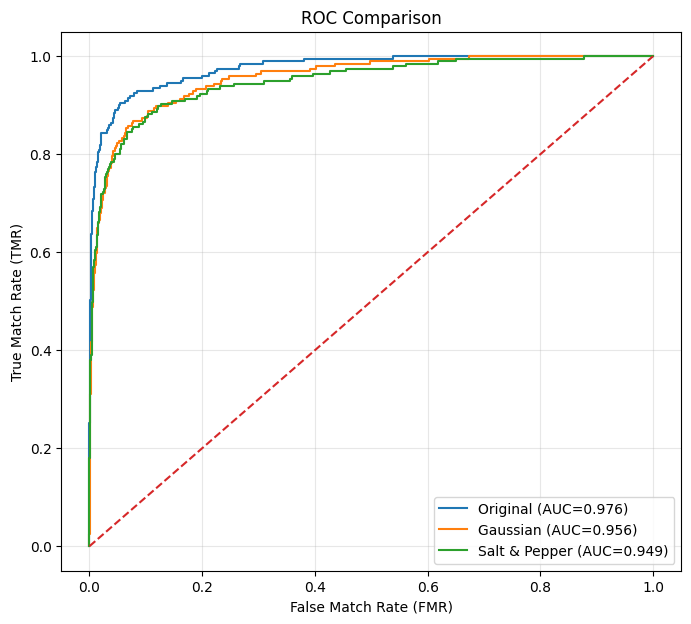

In [ ]:
# CELL 29 — ROC COMPARISON

plt.figure(figsize=(8, 7))

curves = [
    (
        original_curve,
        original_result,
        "Original"
    ),
    (
        gaussian_curve,
        gaussian_result,
        "Gaussian"
    ),
    (
        sp_curve,
        sp_result,
        "Salt & Pepper"
    )
]



for curve, result, label in curves:

    plt.plot(
        curve["fmr"],
        curve["tpr"],
        label=(
            f"{label} "
            f"(AUC={result['auc']:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Match Rate (FMR)"
)

plt.ylabel(
    "True Match Rate (TMR)"
)

plt.title(
    "ROC Comparison"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

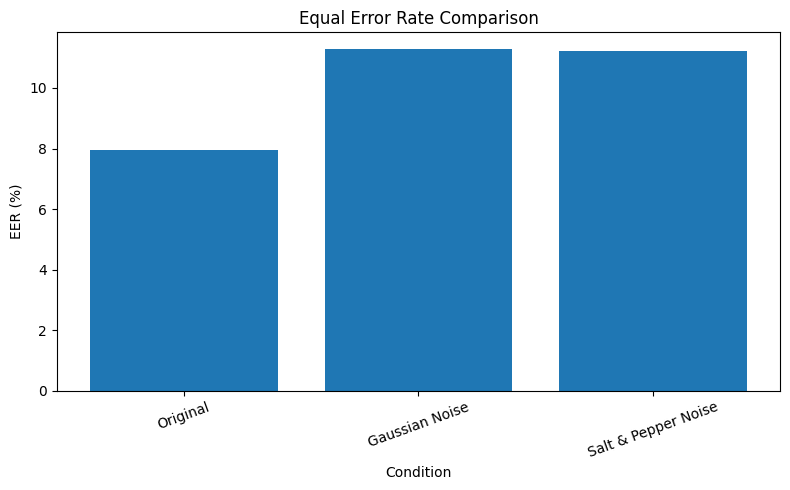

In [35]:
# CELL 30 — EER COMPARISON

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["condition"],
    results_df["eer_percent"]
)

plt.ylabel(
    "EER (%)"
)

plt.xlabel(
    "Condition"
)

plt.title(
    "Equal Error Rate Comparison"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

,condition,detection_rate_percent
0,Original,99.75
1,Gaussian Noise,99.50
2,Salt & Pepper Noise,98.99


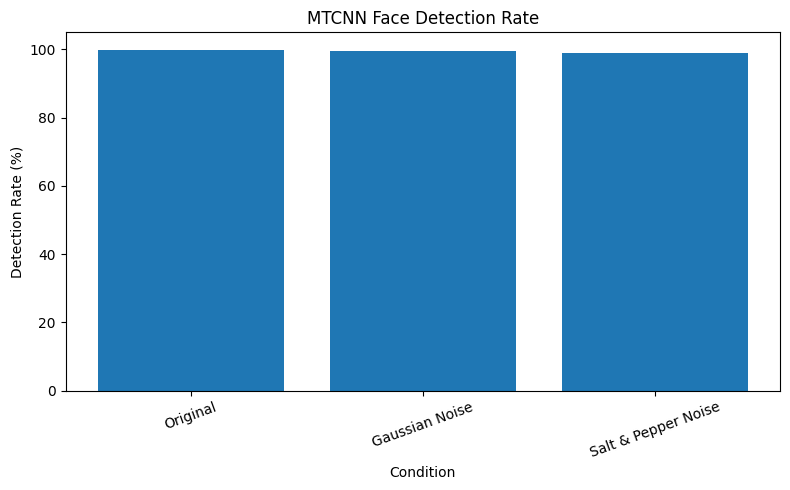

In [36]:
# CELL 31 — MTCNN DETECTION COMPARISON

detection_summary = pd.DataFrame({
    "condition": [
        "Original",
        "Gaussian Noise",
        "Salt & Pepper Noise"
    ],
    "detection_rate_percent": [
        detection_df[
            "face_detected"
        ].mean() * 100,

        gaussian_detection[
            "detected"
        ].mean() * 100,

        sp_detection[
            "detected"
        ].mean() * 100
    ]
})

display(
    detection_summary.round(2)
)

plt.figure(figsize=(8, 5))

plt.bar(
    detection_summary["condition"],
    detection_summary[
        "detection_rate_percent"
    ]
)

plt.ylabel(
    "Detection Rate (%)"
)

plt.xlabel(
    "Condition"
)

plt.title(
    "MTCNN Face Detection Rate"
)

plt.ylim(0, 105)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()